# Analysis: Ukrainian Researchers' Affiliations, 2018–2024

Three questions based on the cleaned panel:

1. How did Ukraine-based affiliations evolve over time?
2. Of authors who had a UA affiliation before 2022, where do they appear after?
3. Do migration patterns differ by research field?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

panel = pd.read_parquet("../data/clean/author_year_country.parquet")
con = sqlite3.connect("../data/clean/works.db")
print("raw panel:", panel.shape)
panel.head()

raw panel: (29162, 5)


,author_id,author_name,year,country_code,n_works
0,https://openalex.org/A5000004161,Małgorzata Ulewicz,2020,PL,1
1,https://openalex.org/A5000004691,Carl A. Latkin,2020,US,2
2,https://openalex.org/A5000005327,V. S. Romanyuk,2019,UA,1
3,https://openalex.org/A5000005327,V. S. Romanyuk,2023,UA,2
4,https://openalex.org/A5000005426,Tkachuk Svitlana,2024,UA,1


## Sample

OpenAlex returns works with ≥1 UA affiliation, including pure foreign co-authors. I restrict the panel to authors who had a UA affiliation at least once in 2018–2024.

In [2]:
ua_authors = set(panel.query("country_code == 'UA'")["author_id"].unique())
panel_ua = panel[panel["author_id"].isin(ua_authors)].copy()

print(f"All authors in raw panel: {panel['author_id'].nunique()}")
print(f"UA-affiliated cohort: {len(ua_authors)}")
print(f"Filtered panel rows: {len(panel_ua)} (was {len(panel)})")
panel_ua.head(10)

All authors in raw panel: 18898
UA-affiliated cohort: 8990
Filtered panel rows: 13609 (was 29162)


,author_id,author_name,year,country_code,n_works
2,https://openalex.org/A5000005327,V. S. Romanyuk,2019,UA,1
3,https://openalex.org/A5000005327,V. S. Romanyuk,2023,UA,2
4,https://openalex.org/A5000005426,Tkachuk Svitlana,2024,UA,1
9,https://openalex.org/A5000034170,Svitlana Hrechana,2020,UA,1
14,https://openalex.org/A5000041550,Nazar Podolchak,2019,UA,1
15,https://openalex.org/A5000041550,Nazar Podolchak,2021,UA,2
16,https://openalex.org/A5000041550,Nazar Podolchak,2022,UA,3
20,https://openalex.org/A5000056347,Hanna Fotina,2021,UA,1
22,https://openalex.org/A5000070844,Olga Kuzmuk,2023,UA,1
29,https://openalex.org/A5000071219,Anastasiia Zerkal,2020,UA,1


## Q1. Share of UA-based affiliations over time

For the UA cohort, what fraction of affiliation–year observations is in Ukraine?

In [3]:
q1 = (panel_ua.assign(is_ua=(panel_ua["country_code"] == "UA").astype(int))
      .groupby("year")
      .agg(n_rows=("is_ua", "size"), n_ua=("is_ua", "sum"))
      .assign(share_ua=lambda d: d["n_ua"] / d["n_rows"]))
q1

,n_rows,n_ua,share_ua
year,,,
2018,1111,1010,0.909091
2019,1663,1423,0.855683
2020,2466,2189,0.887672
2021,2709,2405,0.887781
2022,2235,1956,0.875168
2023,2205,1761,0.798639
2024,1220,976,0.800000


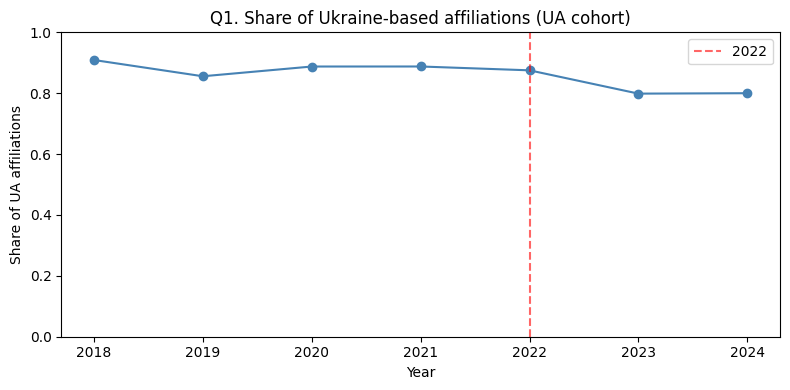

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(q1.index, q1["share_ua"], marker="o", color="steelblue")
ax.axvline(2022, color="red", linestyle="--", alpha=0.6, label="2022")
ax.set_ylim(0, 1)
ax.set_xlabel("Year"); ax.set_ylabel("Share of UA affiliations")
ax.set_title("Q1. Share of Ukraine-based affiliations (UA cohort)")
ax.legend(); plt.tight_layout(); plt.show()

## Q2. Where do pre-2022 UA authors appear after 2022?

Pre-2022 cohort: authors with a UA affiliation in 2018–2021.
Destinations: non-UA countries where they show up in 2022–2024.

This proxies affiliation shifts, not physical relocation.

In [5]:
pre_ua = set(panel_ua.query("year < 2022 and country_code == 'UA'")["author_id"])
print(f"pre-2022 UA cohort: {len(pre_ua)} authors")

post = panel_ua.query("year >= 2022 and author_id in @pre_ua and country_code != 'UA'")
destinations = (post.groupby("country_code")["author_id"].nunique()
                .sort_values(ascending=False).head(10))
destinations

pre-2022 UA cohort: 5845 authors


country_code
PL    57
US    28
SK    25
GB    20
HU    19
CN    14
DE    12
LT    11
CZ    10
CH     9
Name: author_id, dtype: int64

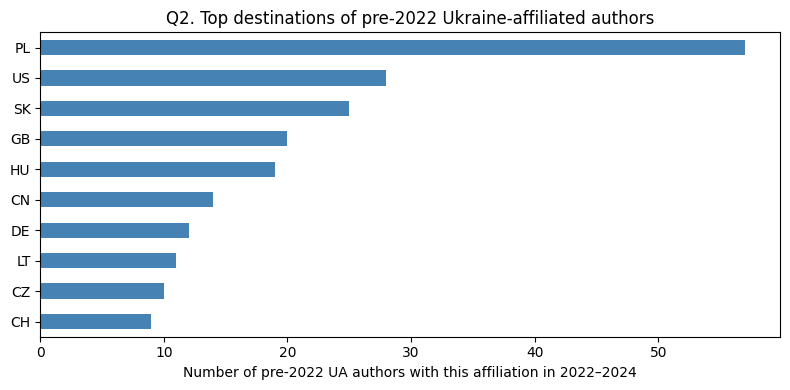

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
destinations.plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Number of pre-2022 UA authors with this affiliation in 2022–2024")
ax.set_ylabel("")
ax.set_title("Q2. Top destinations of pre-2022 Ukraine-affiliated authors")
plt.tight_layout(); plt.show()

## Q3. By research field

For each author's dominant primary_concept, the share of pre-2022 UA authors with a non-UA affiliation in 2022–2024.

In [7]:
# Get each author's most common primary_concept across their works
author_field = pd.read_sql("""
    SELECT a.author_id, w.primary_concept, COUNT(*) AS n
    FROM authorships a
    JOIN works w ON a.work_id = w.work_id
    WHERE a.author_id IS NOT NULL AND w.primary_concept IS NOT NULL
    GROUP BY a.author_id, w.primary_concept
""", con)

# Pick top concept per author
dominant = (author_field.sort_values(["author_id", "n"], ascending=[True, False])
            .drop_duplicates("author_id")
            [["author_id", "primary_concept"]])
print(f"authors with assigned field: {len(dominant)}")
dominant.head()

authors with assigned field: 20151


,author_id,primary_concept
0,https://openalex.org/A5000004161,Alternative energy
1,https://openalex.org/A5000004691,Health psychology
3,https://openalex.org/A5000005327,Mathematics
4,https://openalex.org/A5000005426,Sustainable development
5,https://openalex.org/A5000005783,Medicine


In [8]:
# For each pre-2022 UA author, did they appear abroad in 2022–2024?
moved = set(post["author_id"])

cohort = pd.DataFrame({"author_id": list(pre_ua)})
cohort["moved"] = cohort["author_id"].isin(moved).astype(int)
cohort = cohort.merge(dominant, on="author_id", how="left")

field_stats = (cohort.dropna(subset=["primary_concept"])
               .groupby("primary_concept")
               .agg(n_authors=("author_id", "size"), n_moved=("moved", "sum"))
               .assign(share_moved=lambda d: d["n_moved"] / d["n_authors"])
               .query("n_authors >= 50")
               .sort_values("share_moved", ascending=False)
               .head(15))
field_stats

,n_authors,n_moved,share_moved
primary_concept,,,
Renewable energy,67,10,0.149254
Sustainable development,96,6,0.062500
Agriculture,106,6,0.056604
Mathematics,63,3,0.047619
Ukrainian,132,6,0.045455
Agrarian society,97,4,0.041237
Business,293,11,0.037543
Computer science,253,8,0.031621
Economic security,65,2,0.030769


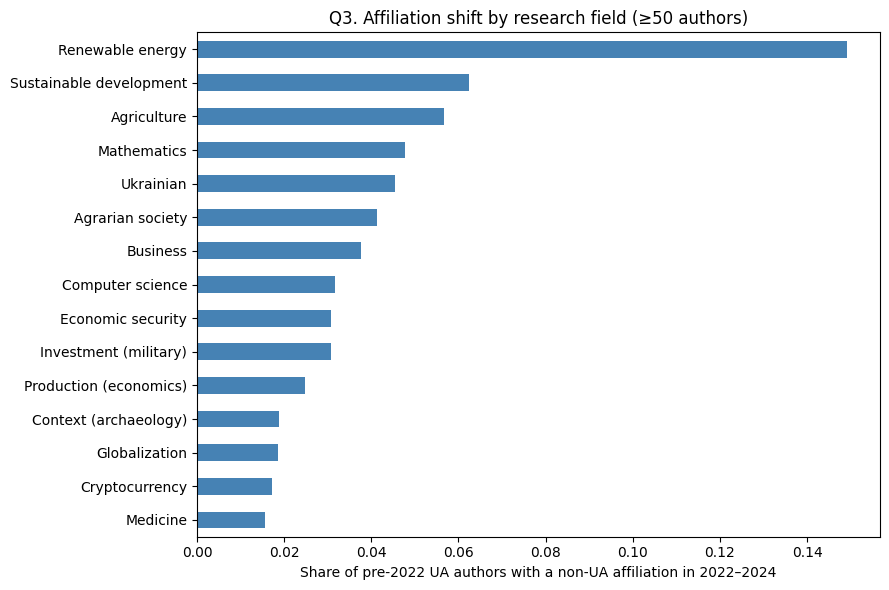

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
field_stats["share_moved"].plot(kind="barh", ax=ax, color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Share of pre-2022 UA authors with a non-UA affiliation in 2022–2024")
ax.set_ylabel("")
ax.set_title("Q3. Affiliation shift by research field (≥50 authors)")
plt.tight_layout(); plt.show()

## Findings

- **Q1.** UA-share held at 0.86–0.91 in 2018–2022, dropped to 0.80 in 2023–2024. Consistent with the usual ~1-year publication lag.
- **Q2.** Top destinations: PL (57), US (28), SK (25), GB (20), HU (19). Neighbours and the anglosphere.
- **Q3.** Field shares range from ~15% (Renewable energy, n=67) to ~1.5% (Medicine, n=64). Higher rates are concentrated in sub-fields with stronger international policy/funding ties (renewable energy, sustainable development). Per-field samples are small — suggestive only.

## Limitations

- 5,000-work sample from one concept; illustrative, not representative.
- Affiliation shift ≠ relocation.
- 2024 is partial — OpenAlex indexes works with a lag; the 2024 drop reflects incomplete indexing as well as actual patterns.
- OpenAlex Concepts are deprecated; Topics would classify better.
- Author IDs come from OpenAlex without independent verification.